In [4]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE" # tells OpenMP to not complain if it notices that two copies of OpenMP are loaded.

from IPython.display import Video
from IPython.display import Audio as play_audio
from torchvision.utils import make_grid
from torchcodec.encoders import VideoEncoder

def play_video(encoded_bytes):
    return Video(data=encoded_bytes.numpy().tobytes(),
                embed=True, width=640, height=360, mimetype="video/mp4")

import matplotlib.pyplot as plt

import sys
sys.path.append('../../../')

import math
import numpy as np

Set warmup steps= 17880


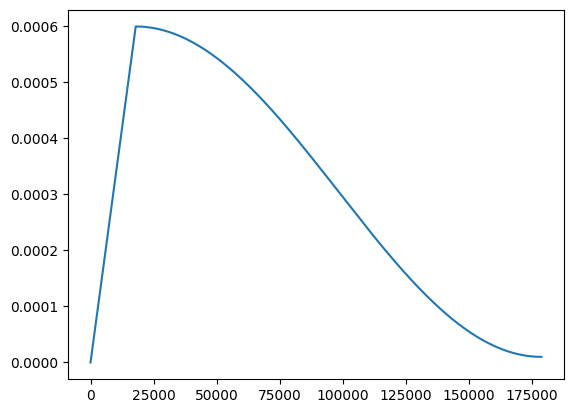

In [5]:
base_value=0.0006
final_value=1e-05
epochs=300
niter_per_ep=596
warmup_epochs=30
start_warmup_value=0
warmup_steps=-1


warmup_schedule=np.array([])
warmup_iters=warmup_epochs*niter_per_ep
if warmup_steps>0: warmup_iters=warmup_steps
print(f"Set warmup steps= {warmup_iters}")
if warmup_epochs>0: warmup_schedule=np.linspace(start_warmup_value, base_value, warmup_iters)
iters=np.arange(epochs*niter_per_ep-warmup_iters)
schedule=np.array([
    final_value+0.5*(base_value-final_value)*
    (1+math.cos(math.pi*i/len(iters))) for i in iters
])
schedule=np.concatenate((warmup_schedule, schedule))
assert len(schedule)==epochs*niter_per_ep

plt.plot(schedule)

In [6]:
type(schedule), schedule.dtype, schedule.shape

(numpy.ndarray, dtype('float64'), (178800,))